In [1]:
# %pip install llama-index-llms-zhipuai

In [2]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.core import Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.zhipuai import ZhipuAI
# from llama_index.llms.openai import OpenAI

In [3]:
from dotenv import load_dotenv
import os

load_dotenv() 
api_key = os.getenv("ZAI_API_KEY")
if api_key is None:
    print("错误：环境变量'ZAI_API_KEY'未设置！")
else:
    print(f"成功获取到API Key: {api_key[:10]}...")

成功获取到API Key: 9555d0d620...


In [4]:
# 使用本地拉取的bge-m3
Settings.embed_model = HuggingFaceEmbedding(model_name="./model/bge-m3")

Settings.llm = ZhipuAI(
    model="glm-4", 
    api_key=os.getenv("ZAI_API_KEY"),
)

# Settings.llm = OpenAI(
#     model="glm-4.6",
#     temperature=0.7,
#     openai_api_key=os.getenv("ZAI_API_KEY"),
#     openai_api_base="https://open.bigmodel.cn/api/paas/v4/",
#     max_tokens=2000
# )

# Settings.llm = OpenAI(
#     model="gpt-4",
#     openai_api_key=os.getenv("OPENAI_API_KEY"),
#     max_tokens=2000
# )


In [5]:
documents = SimpleDirectoryReader("./data").load_data()

In [6]:
index = VectorStoreIndex.from_documents(documents)

In [7]:
query_engine = index.as_query_engine(llm=Settings.llm)

In [8]:
response = query_engine.query("中文回答：1000米中段的岩体质量如何")
print(response.response)

2025-10-28 12:10:39,481 - INFO - HTTP Request: POST https://open.bigmodel.cn/api/paas/v4/chat/completions "HTTP/1.1 200 OK"


根据文件内容，1000米中段的岩体质量分级结果是通过RMR分级方法得出的。该方法的评价结果显示，矿体中的结构面大多为闭合状态，少部分呈张开状态且一般无充填物，结构面迹线长度一般大于1米，表面光滑、平坦、粗糙均有，风化程度一般未风化或局部轻微风化，结构面特点明显、整体较发育。具体数值上，矿体的单轴抗压强度评分为87MPa，RQD（岩石质量指标）为71.77%，这些参数表明该区域的岩体质量较好。


In [9]:
response = query_engine.query("中文回答：列出微震监测系统监测数据统计")
print(response.response)

2025-10-28 12:10:42,624 - INFO - HTTP Request: POST https://open.bigmodel.cn/api/paas/v4/chat/completions "HTTP/1.1 200 OK"


（一）监测数据统计

1. 导入不同厂商、不同型号微震监测数据列表；
2. 数据的读取显示和存储；
3. 数据格式转换；
4. 数据筛选，包括时间、地点、震级等；
5. 数据排序，根据时间、震级等；
6. 数据统计，包括震级频数、能量频数、震源深度分布等；
7. 数据列表自定义输出，生成各类统计报表；
8. 管理不同工程的监测数据统计。


In [10]:
response = query_engine.query("中文回答：有无水平监测台网模拟精度云图，为我列出图片文件名字（如image_000000_523）的列表，不要添加任何额外的解释或总结")
print(response.response)

2025-10-28 12:11:01,910 - INFO - HTTP Request: POST https://open.bigmodel.cn/api/paas/v4/chat/completions "HTTP/1.1 200 OK"


image_000053_4ca292c6fb50aa0425fb8a152fb1e4aaf1adc48c34e6a53aa685f9a8096a2103
image_000054_65771062ced99c044d59c302e5063f1e8bebe004e2745b667a36773877c94a78
image_000055_b6a3c02d4ceb7e0c58a81364a76db56507beccf574a54b86c131fb479cdb5906
image_000056_a8baea7277e6789b54aba16bacdd23c9efb3345975aa158368dab11cbfa67d10
image_000057_c09d9eb423dcce2c0eb4bf1ee06d3b1c6e9b0d713ce81fa657b0cda69fb7e42e
image_000058_b1b5c386b8f7593cf490a8317ec374851c926ddd5832d94fcb3fa39bf121875b
image_000059_4141a49d5ea257f7408334a95866dc8b82c94dd29d7d8c5ef5e31ab9ed034635
image_000068_dd42d8bd325b5abf3b08e73ce18aea99fd37c4fd04f63f3403fe763e668cf497
image_000069_65771062ced99c044d59c302e5063f1e8bebe004e2745b667a36773877c94a78
image_000070_3c9ec8cf168c43b8c056be5fce45f817dada671e213cb4d21ff6b04731bd4588
image_000071_9e6089998eac66527d4dfc7964f4bb639eab9003bbcdc0e251181b10e5f21eab
image_000072_b4684e6daf9586b847c48438aa091f55e1bcf4898494662ebd0b3ceb0d160be8
image_000073_b1b5c386b8f7593cf490a8317ec374851c926ddd5832d94fcb3

In [ ]:
from IPython.display import Image, display

text = response.response

# 按行分割
image_list = [line.strip() for line in text.splitlines() if line.strip()]

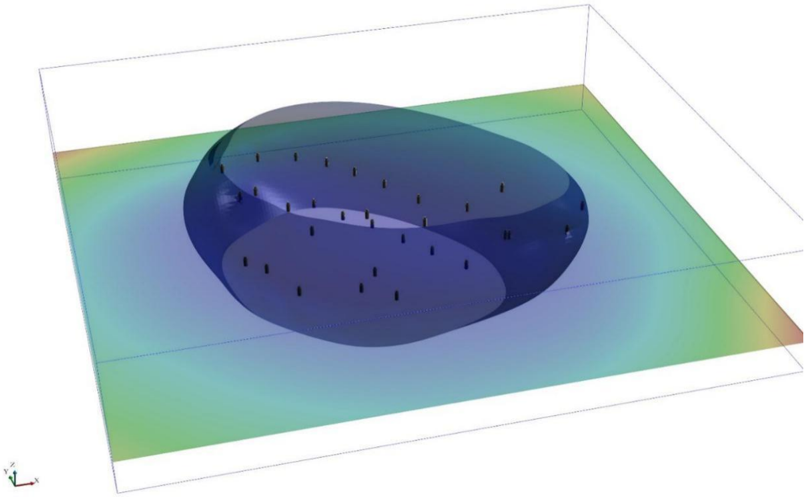

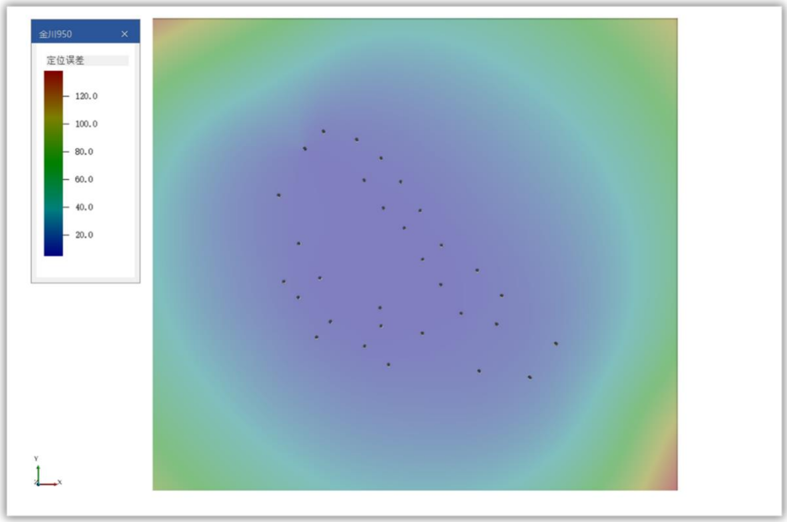

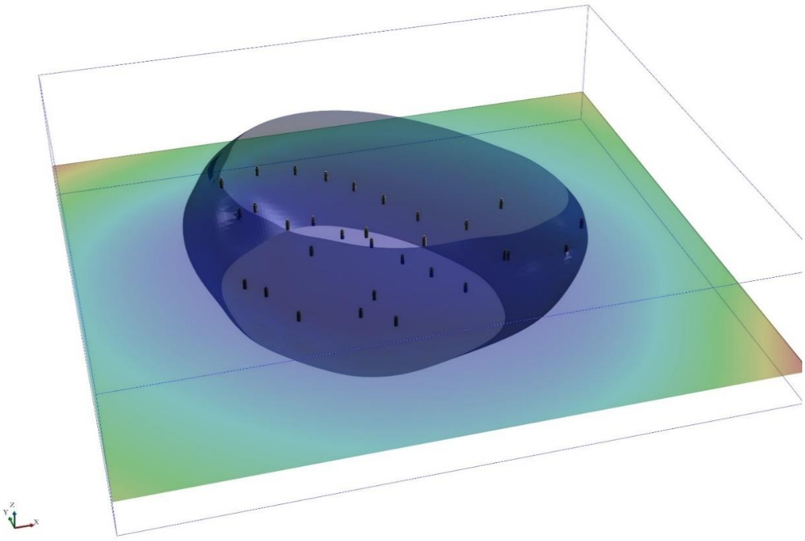

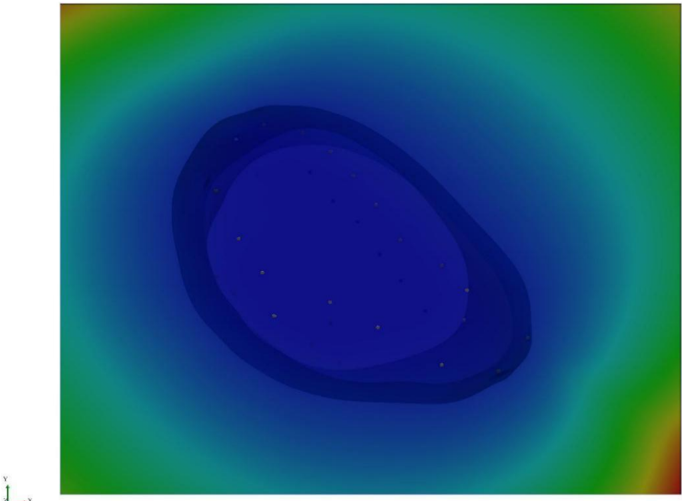

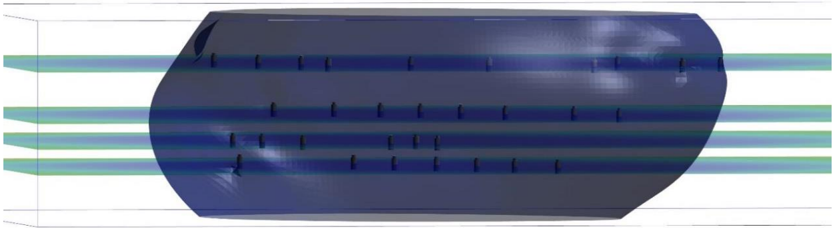

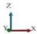

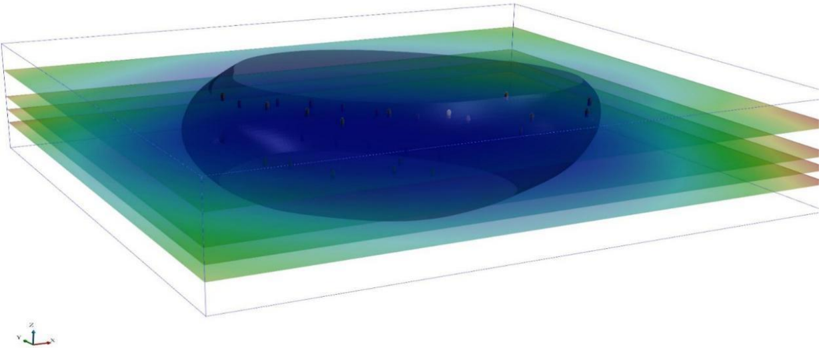

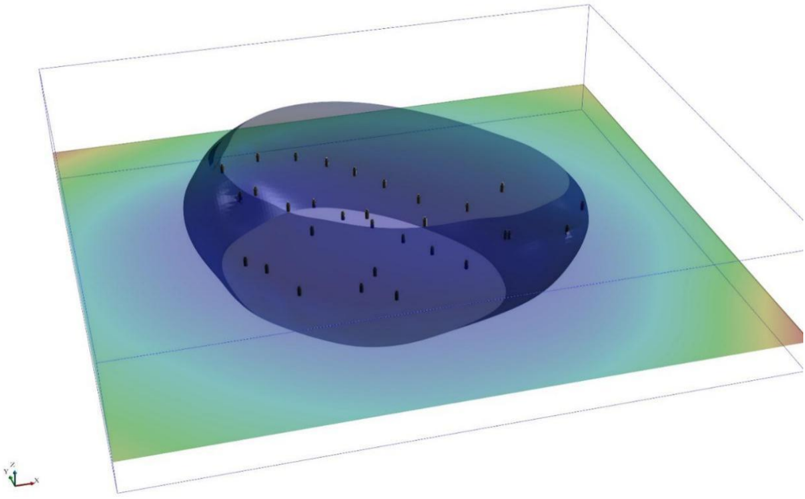

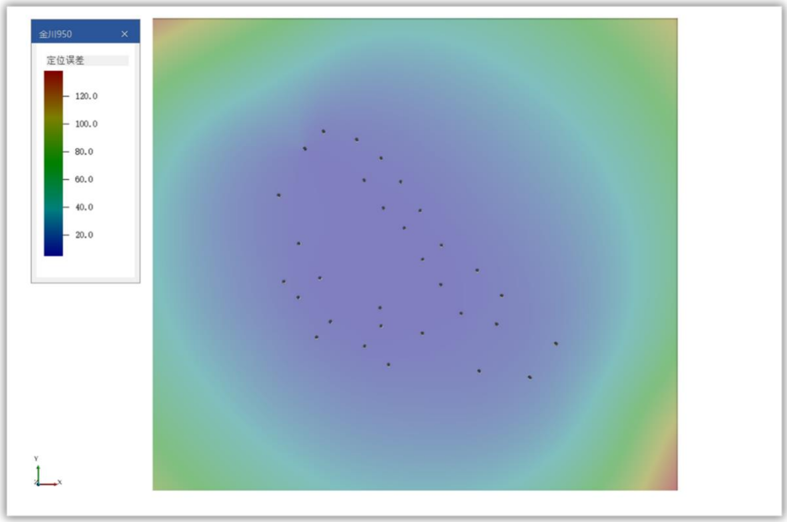

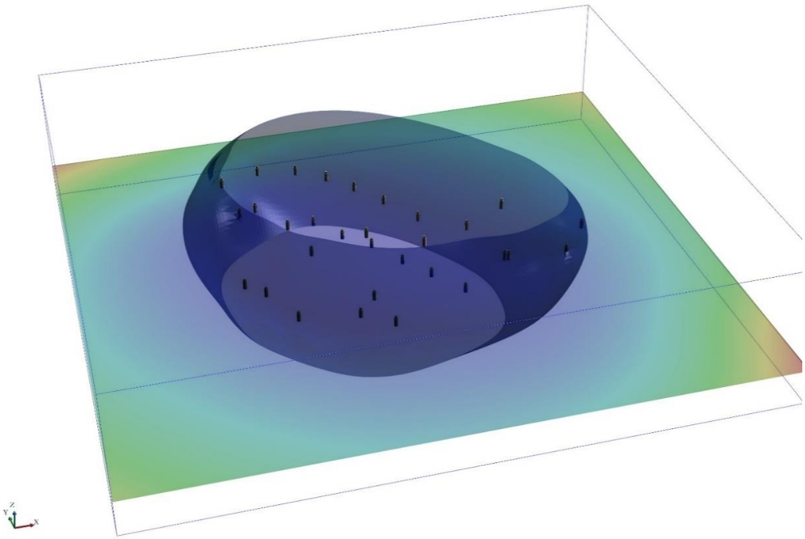

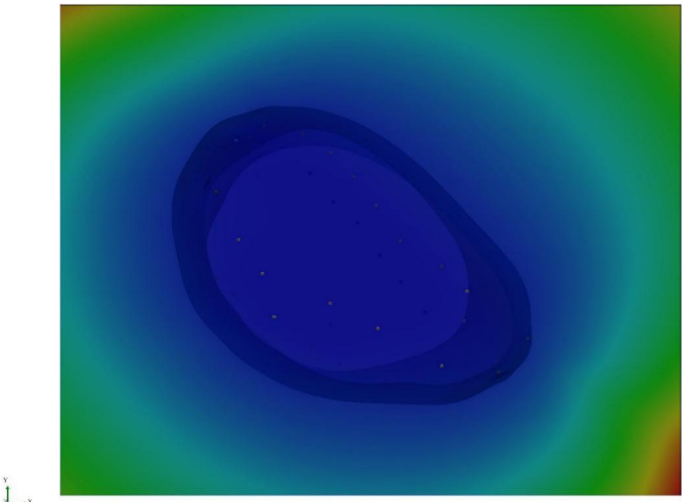

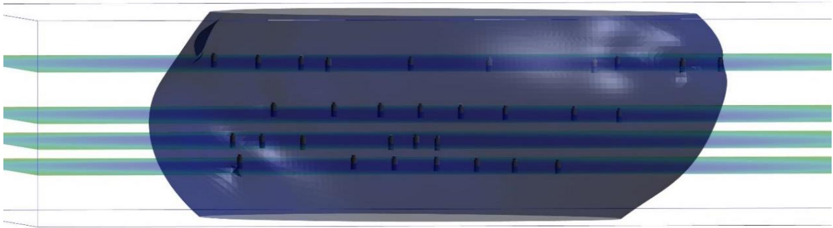

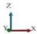

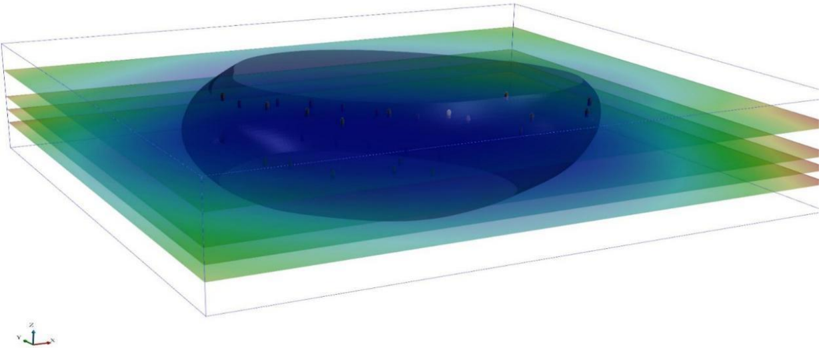

In [17]:
from pathlib import Path
baseImgDir = Path("data") / "scratch" / "金川集团二矿区1000m中段水平矿柱回采智能监测及对策研究结题报告(打印版)-with-image-refs_artifacts"
for img_path in image_list:
    img_path += ".png"
    filename = baseImgDir / img_path
    display(Image(filename=filename))